### **Importing Libraries**


In [1]:
import os
import torch
import torchvision
import random
import matplotlib.pyplot as plt
import torchvision.models as models
import torch.nn as nn
from collections import Counter
import torch.nn.functional as F
from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

### **Reading Data**


In [3]:
data_dir = "/kaggle/input/garbage-classification/Garbage classification/Garbage classification"

classes = os.listdir(data_dir)
print(classes)

['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']


### **Transformations**


In [4]:
transformations = transforms.Compose(
    [transforms.Resize((224, 224)), transforms.ToTensor()])

dataset = ImageFolder(data_dir, transform=transformations)

In [5]:
labels = dataset.targets

count_per_class = Counter(labels)

for i, class_name in enumerate(dataset.classes):
    print(f"{class_name:<10} → {count_per_class[i]} samples")

print("="*25)

total_samples = sum(count_per_class.values())
print("Total samples:", total_samples)

cardboard  → 403 samples
glass      → 501 samples
metal      → 410 samples
paper      → 594 samples
plastic    → 482 samples
trash      → 137 samples
Total samples: 2527


### **Display Random Images**


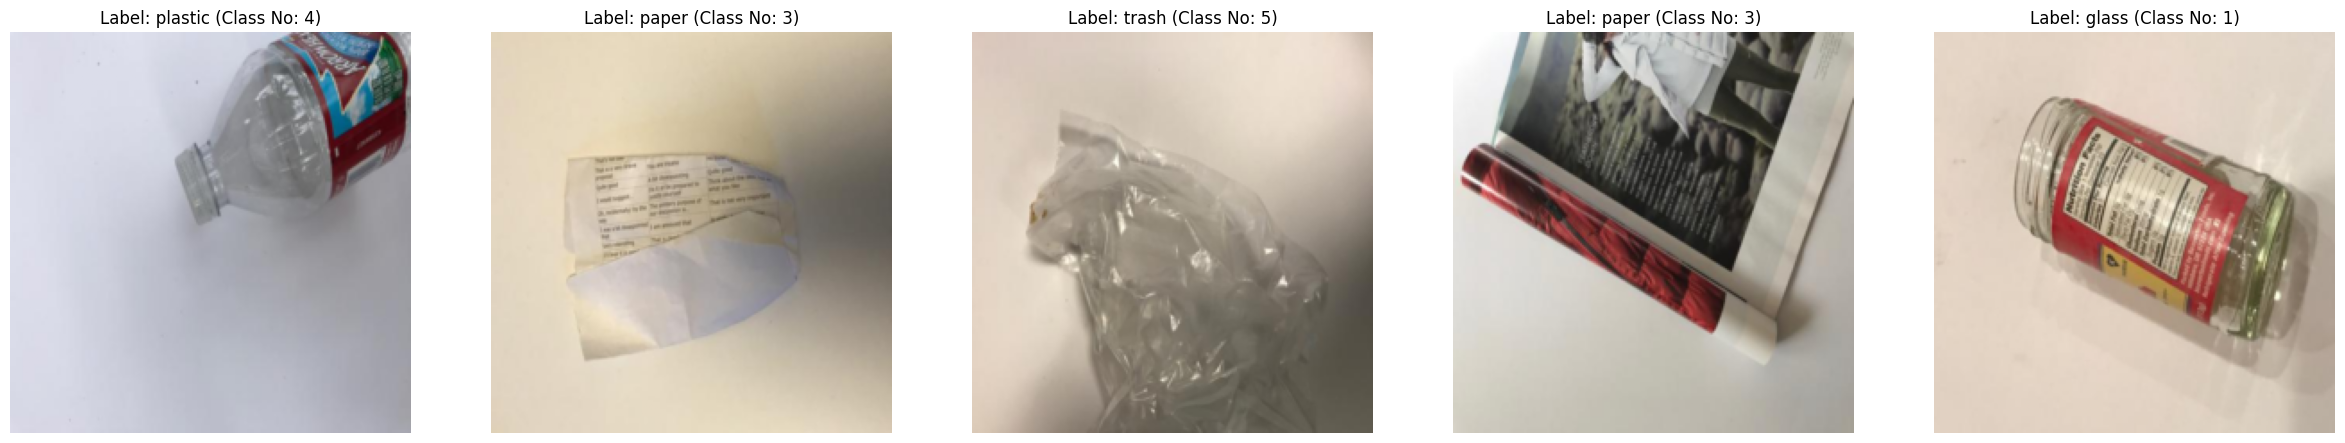

In [6]:
def show_random_samples(num_samples):
    indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(6 * num_samples, 6))

    for i, idx in enumerate(indices):
        img, label = dataset[idx]

        title = f"Label: {dataset.classes[label]} (Class No: {label})"

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img.permute(1, 2, 0))
        plt.title(title)
        plt.axis("off")

    plt.show()


show_random_samples(5)

### **Loading and Splitting Data**


In [7]:
torch.manual_seed(42)
total = len(dataset)

train_size = int(0.70 * total)               # 70%
val_size = int(0.15 * total)              # 15%
test_size = total - train_size - val_size  # 15%

train_ds, val_ds, test_ds = random_split(
    dataset, [train_size, val_size, test_size])


len(train_ds), len(val_ds), len(test_ds)

(1768, 379, 380)

In [8]:
batch_size = 32

train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=batch_size,
                        shuffle=False, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=batch_size,
                         shuffle=False, pin_memory=True)

### **Visualize batches**


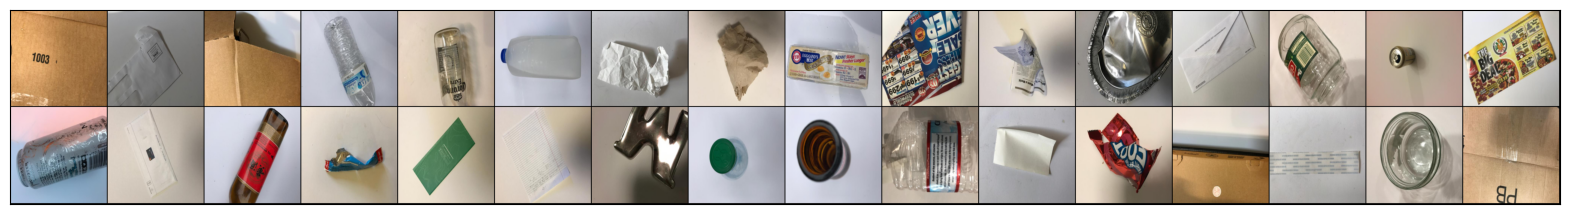

In [9]:
from torchvision.utils import make_grid


def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(20, 20))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=16).permute(1, 2, 0))
        break


# Every Batch from train_loader  Display 32 Picture , we have 55 batch
show_batch(train_loader)

### **Model Base**


In [10]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))


class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels)  # Calculate loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result, is_best=False):
        msg = (
            f"Epoch {epoch} | "
            f"Train Acc: {result['train_acc']:.4f} | "
            f"Train Loss: {result['train_loss']:.4f} | "
            f"Val Loss: {result['val_loss']:.4f} | "
            f"Val Acc: {result['val_acc']:.4f}"
        )
        if is_best:
            msg += "  <-- Saving best model "
        print(msg)

### **We'll be using ResNet50 for classifying images**


In [11]:
import torch.nn as nn
import torchvision.models as models


class ResNet(ImageClassificationBase):
    def __init__(self):
        super().__init__()

        self.network = models.resnet50(pretrained=True)

        # Get number of features of last FC layer
        num_ftrs = self.network.fc.in_features

        # Add Dropout before the final layer
        self.network.fc = nn.Sequential(
            nn.Dropout(p=0.2),               # Dropout probability (20%)
            nn.Linear(num_ftrs, len(dataset.classes))
        )

    def forward(self, xb):
        return self.network(xb)

### **Run On GPU if available**


In [12]:
import torch

# 1) Select the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2) Create the model and move it to the selected device
model = ResNet()
model = model.to(device)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s] 


### **Optimizer**


In [13]:
import torch.optim as optim
opt_func = torch.optim.SGD

optimizer = opt_func(
    model.parameters(),
    lr=1e-3,
    momentum=0.9,
    weight_decay=1e-4
)

### **Fitting Model**


In [14]:
import torch
import torch.nn.functional as F


def fit(epochs, model, train_loader, val_loader, optimizer, device, checkpoint_path="best_model.pth"):
    history = []
    best_val_acc = 0.0  # to track the best validation accuracy

    for epoch in range(epochs):
        # --------- TRAINING ---------
        model.train()
        train_losses = []
        train_correct = 0
        train_total = 0

        for batch in train_loader:
            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)

            # ONE forward pass only
            outputs = model(images)

            # loss (same as training_step was doing)
            loss = F.cross_entropy(outputs, labels)
            train_losses.append(loss)

            # train accuracy from the same outputs
            _, preds = torch.max(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

            # backward + optimize
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        train_loss = torch.stack(train_losses).mean().item()
        train_acc = train_correct / train_total

        # --------- VALIDATION ---------
        model.eval()
        with torch.no_grad():
            val_outputs = []
            for batch in val_loader:
                images, labels = batch
                images = images.to(device)
                labels = labels.to(device)

                out = model.validation_step((images, labels))
                val_outputs.append(out)

            result = model.validation_epoch_end(val_outputs)
            result['train_loss'] = train_loss
            result['train_acc'] = train_acc

        # --------- CHECK IF NEW BEST ---------
        val_acc = result['val_acc']
        is_best = val_acc > best_val_acc

        # --------- PRINT EPOCH RESULT ---------
        model.epoch_end(epoch + 1, result, is_best=is_best)
        history.append(result)

        # --------- CHECKPOINTING ---------
        if is_best:
            best_val_acc = val_acc
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": result['val_loss'],
                    "val_acc": result['val_acc'],
                },
                checkpoint_path,
            )

    return history

In [15]:
epochs = 10
history = fit(epochs, model, train_loader, val_loader, optimizer,
              device, checkpoint_path="best_model.pth")

Epoch 1 | Train Acc: 0.5362 | Train Loss: 1.2435 | Val Loss: 0.8239 | Val Acc: 0.7378  <-- Saving best model 
Epoch 2 | Train Acc: 0.8507 | Train Loss: 0.4873 | Val Loss: 0.5370 | Val Acc: 0.8288  <-- Saving best model 
Epoch 3 | Train Acc: 0.9361 | Train Loss: 0.2465 | Val Loss: 0.3939 | Val Acc: 0.8553  <-- Saving best model 
Epoch 4 | Train Acc: 0.9712 | Train Loss: 0.1368 | Val Loss: 0.3651 | Val Acc: 0.8605  <-- Saving best model 
Epoch 5 | Train Acc: 0.9808 | Train Loss: 0.1072 | Val Loss: 0.3453 | Val Acc: 0.8814  <-- Saving best model 
Epoch 6 | Train Acc: 0.9898 | Train Loss: 0.0624 | Val Loss: 0.4970 | Val Acc: 0.8371
Epoch 7 | Train Acc: 0.9932 | Train Loss: 0.0494 | Val Loss: 0.3853 | Val Acc: 0.8627
Epoch 8 | Train Acc: 0.9943 | Train Loss: 0.0363 | Val Loss: 0.2867 | Val Acc: 0.8949  <-- Saving best model 
Epoch 9 | Train Acc: 0.9983 | Train Loss: 0.0254 | Val Loss: 0.2910 | Val Acc: 0.9079  <-- Saving best model 
Epoch 10 | Train Acc: 0.9983 | Train Loss: 0.0221 | Val Lo

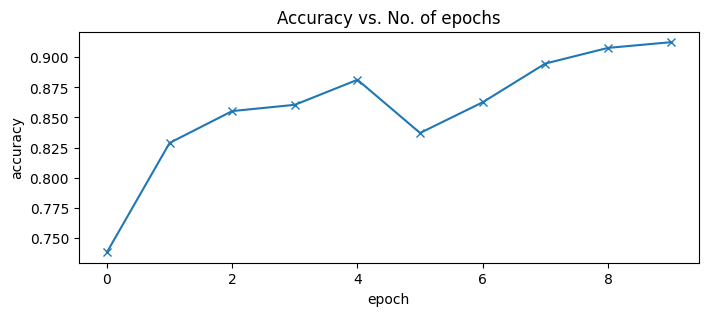

In [16]:
plt.figure(figsize=(8, 3))


def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs')


plot_accuracies(history)

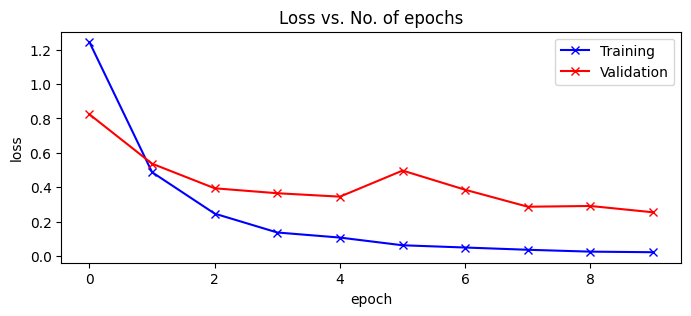

In [17]:
plt.figure(figsize=(8, 3))


def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs')


plot_losses(history)

In [18]:
checkpoint = torch.load("best_model.pth", map_location=device)
model = ResNet().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# evaluate on test_loader
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("="*30)
print(f"Test Acc: {correct/total*100:.3f}%")
print("="*30)

Test Acc: 92.632%


### **Visualizing Predictions**


In [19]:
def predict_image(img, model):
    # Convert image to batch of size 1
    xb = img.unsqueeze(0).to(device)

    # Get predictions
    yb = model(xb)

    # Pick index with highest probability
    _, preds = torch.max(yb, dim=1)

    # Return class label
    return dataset.classes[preds[0].item()]

In [20]:
def show_predictions_grid(images, labels, model, rows=2, cols=3):
    plt.figure(figsize=(3 * cols, 3 * rows))

    for i in range(len(images)):
        img = images[i]
        label = labels[i]
        pred = predict_image(img, model)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img.permute(1, 2, 0))
        plt.title(f"Label: {label}\nPredicted: {pred}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

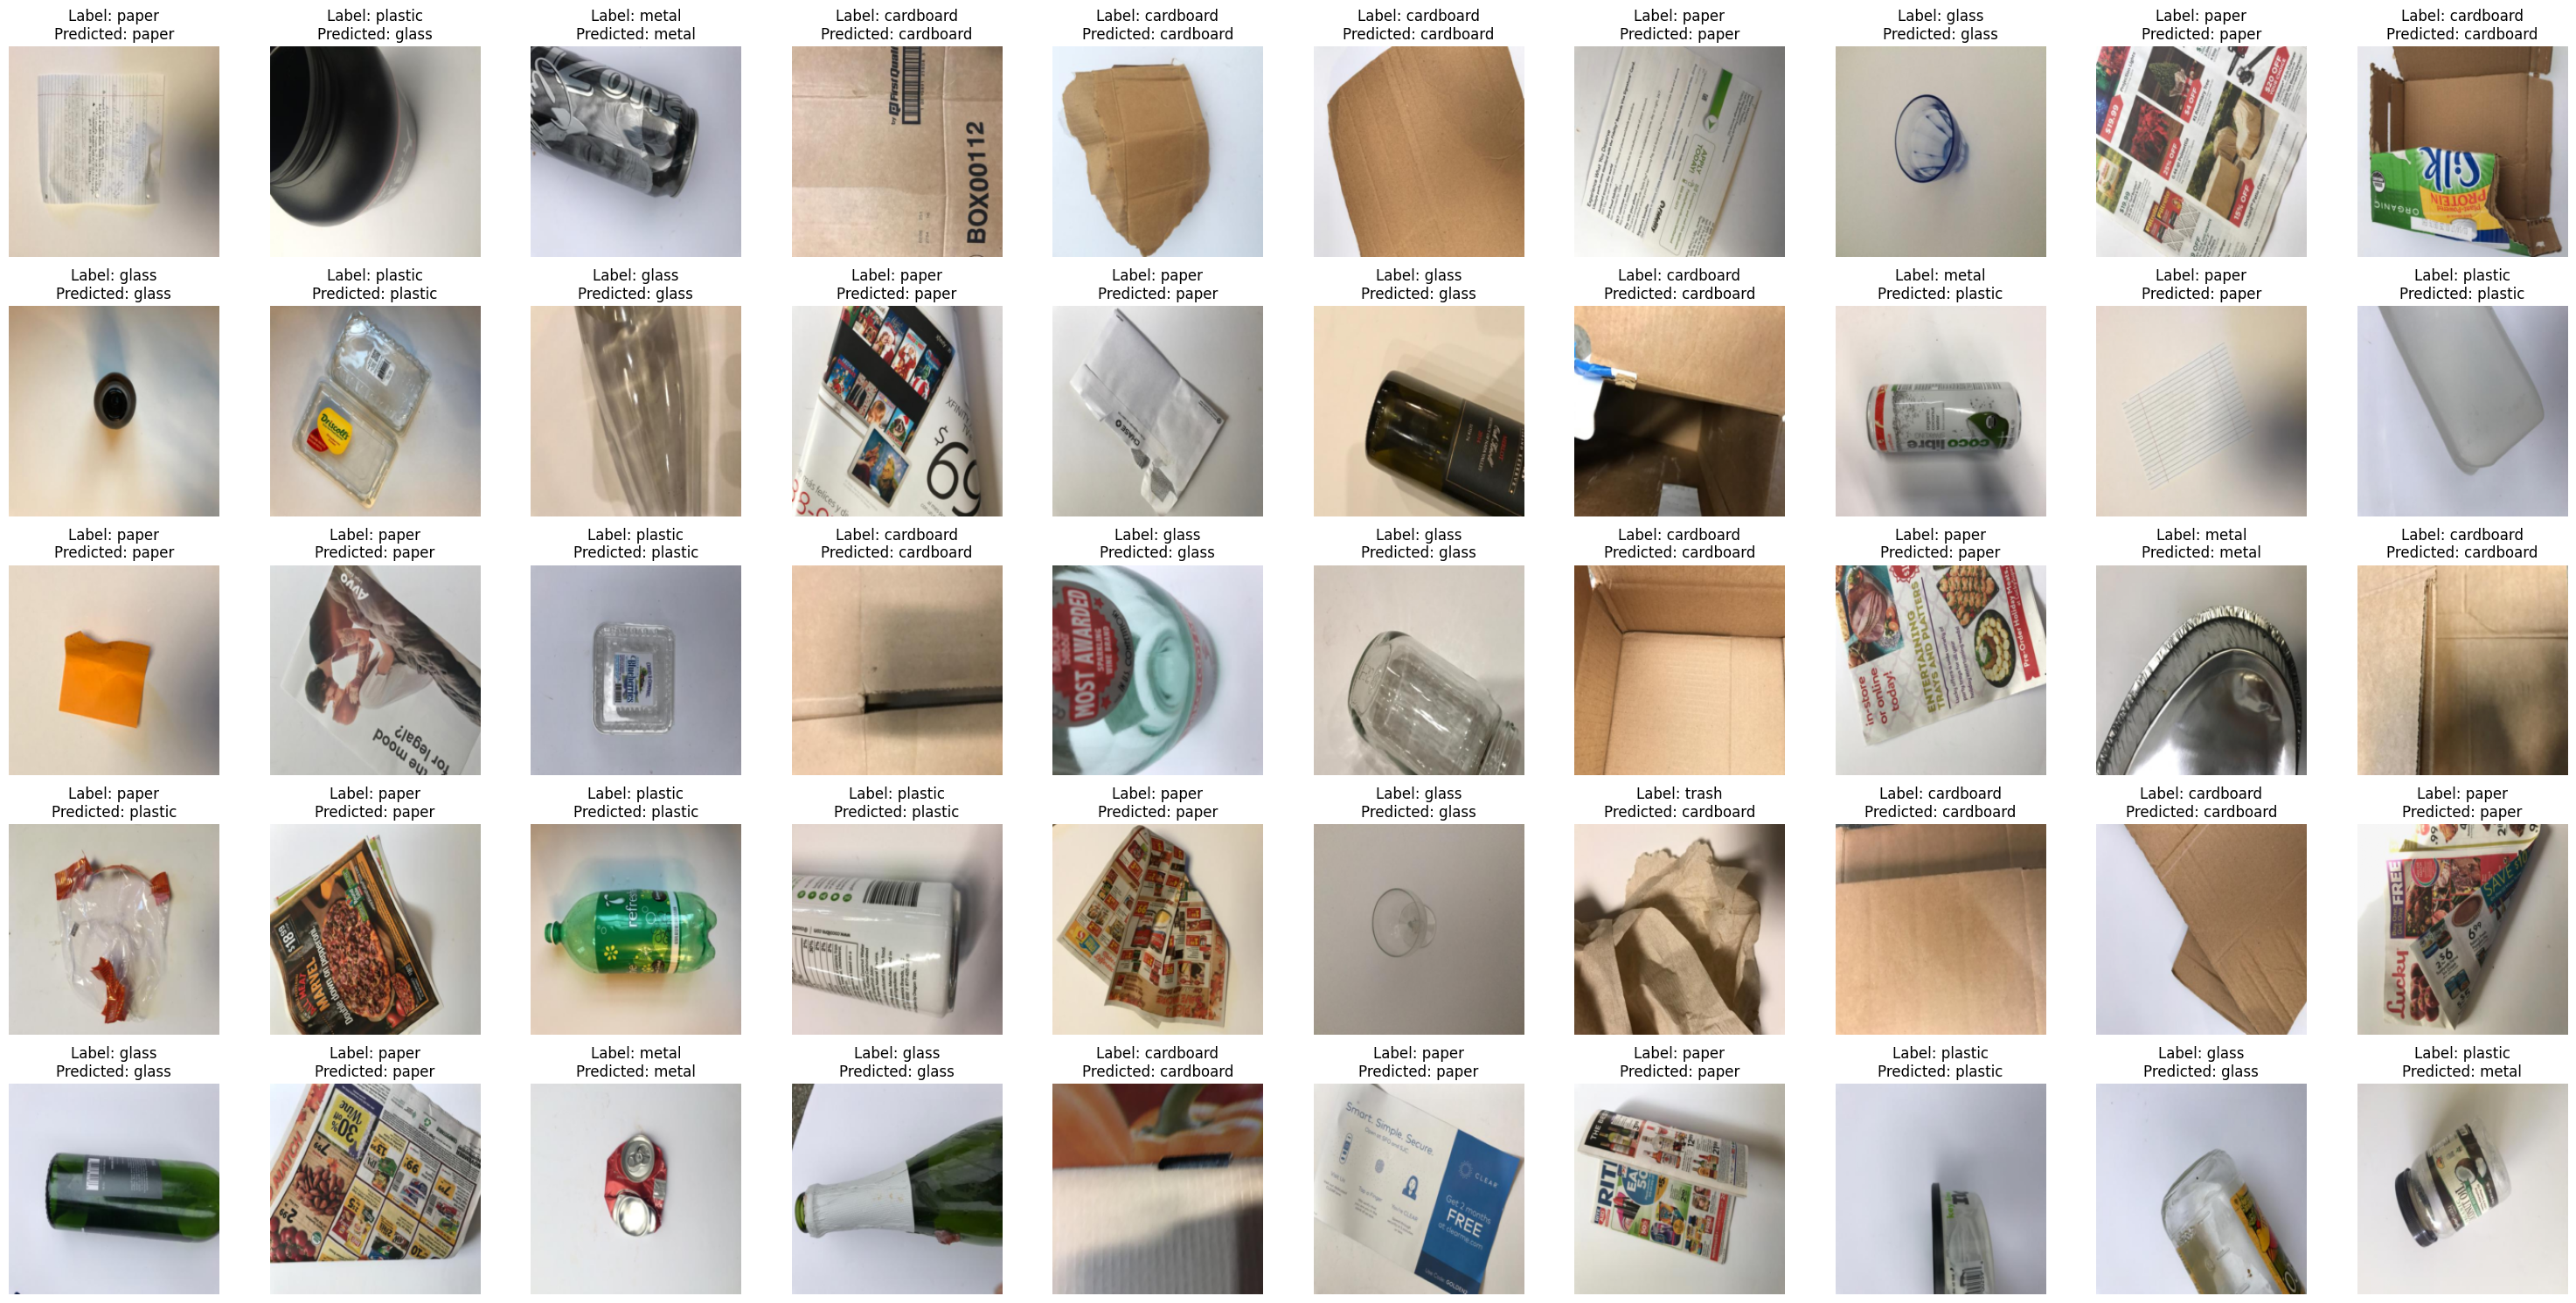

In [21]:
def fetch_samples(loader, n=50):
    imgs, lbls = [], []

    for images, labels in loader:
        imgs.extend(images)
        lbls.extend(labels)

        if len(imgs) >= n:
            break

    imgs = imgs[:n]
    lbls = [dataset.classes[l.item()] for l in lbls[:n]]

    return imgs, lbls


# -------- Display 50 images --------
imgs, lbls = fetch_samples(test_loader, n=50)

show_predictions_grid(imgs, lbls, model, rows=5, cols=10)

Suggesting the Dustbin

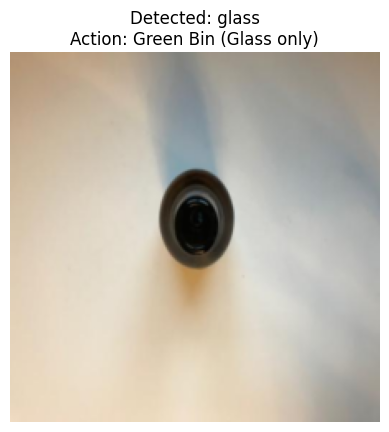

--- Result ---
Item: glass
Target Bin: Green Bin (Glass only)


In [22]:
# 1. Define your mapping (Make sure these match your 'classes' list)
# Convert keys to lowercase to be safe
dustbin_mapping = {
    "paper": "Blue Bin (Recyclable)",
    "cardboard": "Blue Bin (Recyclable)",
    "glass": "Green Bin (Glass only)",
    "metal": "Yellow Bin (Recyclable)",
    "plastic": "Yellow Bin (Recyclable)",
    "trash": "Black Bin (Landfill/General Waste)"
}

# 2. Pick an image from the test set (e.g., image index 10)
index = 10 
img, label = test_ds[index] 

# 3. Predict
prediction = predict_image(img, model)

# 4. Get the suggestion (using .lower() to match our dictionary)
action = dustbin_mapping.get(prediction.lower(), "Check local guidelines")

# 5. Show results
plt.imshow(img.permute(1, 2, 0))
plt.title(f"Detected: {prediction}\nAction: {action}")
plt.axis("off")
plt.show()

print(f"--- Result ---")
print(f"Item: {prediction}")
print(f"Target Bin: {action}")

In [23]:
import os
import torch

# 1. Define the filename
filename = "garmodel-with-acc-93.pth"

# 2. Try to save
try:
    # Save to the specific 'working' directory
    torch.save(model.state_dict(), f"/kaggle/working/{filename}")
    print(f"✅ Success! File saved to: /kaggle/working/{filename}")
except Exception as e:
    print(f"❌ Error: {e}")

# 3. List all files to prove it exists
print("Current files in working directory:", os.listdir('/kaggle/working'))

✅ Success! File saved to: /kaggle/working/garmodel-with-acc-93.pth
Current files in working directory: ['garmodel-with-acc-93.pth', 'best_model.pth', '.virtual_documents']
